In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('/kaggle/input/datasets/ijk037/auction-history-csv/auction_history.csv')

print(df.head())

   period  true_value  mm_signal  mm_bid  mm_ask  mm_num_buys  mm_num_sells  \
0       0      158.40      39.35    0.00  109.35           27             0   
1       1      662.17     704.49  634.49  774.49            0             0   
2       2      133.24     108.14   38.14  178.14            9             0   
3       3      110.05     133.22   63.22  203.22            0             6   
4       4      428.35     395.24  325.24  465.24            0             0   

    mm_pnl  bot_tight_bid  bot_tight_ask  bot_wide_bid  bot_wide_ask  \
0 -1324.23         140.31         250.31          0.00        189.36   
1     0.00         578.01         688.01        554.64        794.64   
2   404.08          74.21         184.21          0.00        186.81   
3   280.95          13.90         123.90          0.00        174.47   
4     0.00         348.60         458.60        317.61        557.61   

   bot_skewed_bid  bot_skewed_ask  bot_noisy_bid  bot_noisy_ask  bot_fade_bid  \
0          

In [3]:
bots = [
    "bot_tight",
    "bot_wide",
    "bot_skewed",
    "bot_noisy",
    "bot_fade"
]

for bot in bots:
    df[f"{bot}_mid"] = (
        df[f"{bot}_bid"] + df[f"{bot}_ask"]
    ) / 2

    df[f"{bot}_spread"] = (
        df[f"{bot}_ask"] - df[f"{bot}_bid"]
    )

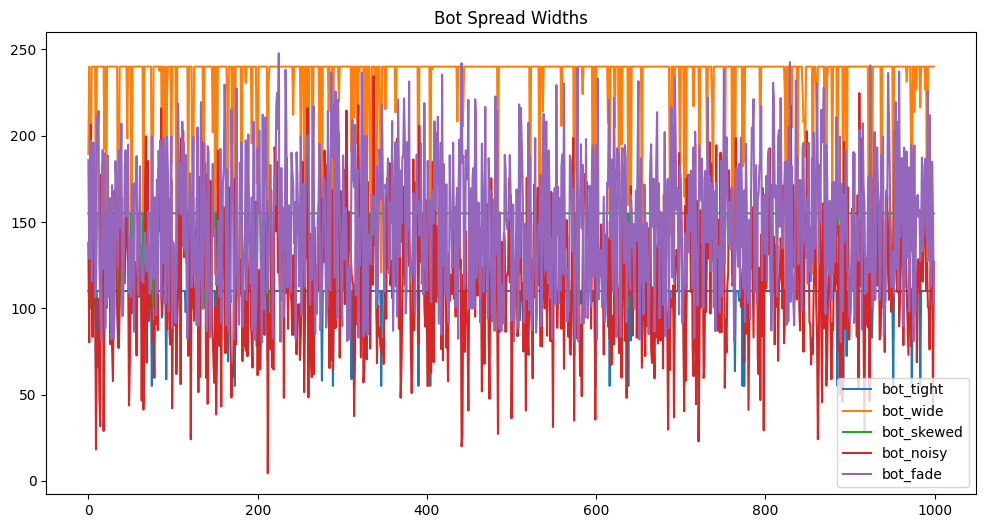

In [4]:
plt.figure(figsize=(12,6))

for bot in bots:
    plt.plot(
        df['period'],
        df[f'{bot}_spread'],
        label=bot
    )

plt.legend()
plt.title("Bot Spread Widths")
plt.show()

In [5]:
def market_make(signal,
                base_spread=40,
                edge_factor=0.05,
                ask_skew=5,
                bid_skew=0):

    spread = base_spread + edge_factor * abs(signal - 500)

    bid = signal - spread - bid_skew
    ask = signal + spread + ask_skew

    bid = max(0, bid)
    ask = min(1200, ask)

    return bid, ask

In [6]:
def simulate_round(true_value,
                   my_bid,
                   my_ask,
                   bot_quotes,
                   num_punters=20,
                   num_counters=2):

    pnl = 0

    for _ in range(num_punters):

        side = np.random.choice(['buy', 'sell'])

        reservation = true_value + np.random.normal(0, 120)

        all_bids = [q[0] for q in bot_quotes] + [my_bid]
        all_asks = [q[1] for q in bot_quotes] + [my_ask]

        best_bid = max(all_bids)
        best_ask = min(all_asks)

        if side == 'buy':

            if reservation > best_ask:

                if my_ask == best_ask:
                    pnl += (my_ask - true_value)

        else:

            if reservation < best_bid:

                if my_bid == best_bid:
                    pnl += (true_value - my_bid)

    for _ in range(num_counters):

        all_bids = [q[0] for q in bot_quotes] + [my_bid]
        all_asks = [q[1] for q in bot_quotes] + [my_ask]

        best_bid = max(all_bids)
        best_ask = min(all_asks)

        if best_ask < true_value:

            if my_ask == best_ask:
                pnl += (my_ask - true_value)

        if best_bid > true_value:

            if my_bid == best_bid:
                pnl += (true_value - my_bid)

    return pnl

In [7]:
def run_simulation(base_spread,
                   edge_factor,
                   ask_skew,
                   bid_skew,
                   rounds=10000):

    total_pnl = 0

    for _ in range(rounds):

        V = np.random.uniform(0, 1000)

        my_signal = V + np.random.normal(0, 50)

        my_bid, my_ask = market_make(
            my_signal,
            base_spread,
            edge_factor,
            ask_skew,
            bid_skew
        )

        row = df.sample(1).iloc[0]

        bot_quotes = []

        for bot in bots:

            bot_bid = row[f"{bot}_bid"]
            bot_ask = row[f"{bot}_ask"]

            bot_quotes.append((bot_bid, bot_ask))

        pnl = simulate_round(
            V,
            my_bid,
            my_ask,
            bot_quotes
        )

        total_pnl += pnl

    return total_pnl / rounds

In [8]:
results = []

base_spreads = [20, 30, 40, 50, 60]
edge_factors = [0.02, 0.05, 0.08]
ask_skews = [0, 5, 10]
bid_skews = [0, 5]

total = (
    len(base_spreads)
    * len(edge_factors)
    * len(ask_skews)
    * len(bid_skews)
)

count = 0

for bs in base_spreads:
    for ef in edge_factors:
        for ask_sk in ask_skews:
            for bid_sk in bid_skews:

                score = run_simulation(
                    base_spread=bs,
                    edge_factor=ef,
                    ask_skew=ask_sk,
                    bid_skew=bid_sk,
                    rounds=5000
                )

                results.append({
                    'base_spread': bs,
                    'edge_factor': ef,
                    'ask_skew': ask_sk,
                    'bid_skew': bid_sk,
                    'score': score
                })

                count += 1

                print(f"{count}/{total} done")

1/90 done
2/90 done
3/90 done
4/90 done
5/90 done
6/90 done
7/90 done
8/90 done
9/90 done
10/90 done
11/90 done
12/90 done
13/90 done
14/90 done
15/90 done
16/90 done
17/90 done
18/90 done
19/90 done
20/90 done
21/90 done
22/90 done
23/90 done
24/90 done
25/90 done
26/90 done
27/90 done
28/90 done
29/90 done
30/90 done
31/90 done
32/90 done
33/90 done
34/90 done
35/90 done
36/90 done
37/90 done
38/90 done
39/90 done
40/90 done
41/90 done
42/90 done
43/90 done
44/90 done
45/90 done
46/90 done
47/90 done
48/90 done
49/90 done
50/90 done
51/90 done
52/90 done
53/90 done
54/90 done
55/90 done
56/90 done
57/90 done
58/90 done
59/90 done
60/90 done
61/90 done
62/90 done
63/90 done
64/90 done
65/90 done
66/90 done
67/90 done
68/90 done
69/90 done
70/90 done
71/90 done
72/90 done
73/90 done
74/90 done
75/90 done
76/90 done
77/90 done
78/90 done
79/90 done
80/90 done
81/90 done
82/90 done
83/90 done
84/90 done
85/90 done
86/90 done
87/90 done
88/90 done
89/90 done
90/90 done


In [9]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by='score',
    ascending=False
)

print(results_df.head(10))

    base_spread  edge_factor  ask_skew  bid_skew       score
89           60         0.08        10         5  133.769443
87           60         0.08         5         5  131.860881
84           60         0.08         0         0  129.384658
88           60         0.08        10         0  128.719026
86           60         0.08         5         0  127.515282
81           60         0.05         5         5  127.457179
85           60         0.08         0         5  126.157775
71           50         0.08        10         5  125.606517
82           60         0.05        10         0  125.255082
78           60         0.05         0         0  123.228347


In [10]:
best = results_df.iloc[0]

print("\nBEST STRATEGY")
print(best)


BEST STRATEGY
base_spread     60.000000
edge_factor      0.080000
ask_skew        10.000000
bid_skew         5.000000
score          133.769443
Name: 89, dtype: float64


In [11]:
signals = np.arange(0, 1001, 50)

submission = []

for s in signals:

    bid, ask = market_make(
        signal=s,
        base_spread=best['base_spread'],
        edge_factor=best['edge_factor'],
        ask_skew=best['ask_skew'],
        bid_skew=best['bid_skew']
    )

    submission.append({
        'signal': s,
        'bid': round(bid, 2),
        'ask': round(ask, 2)
    })

submission_df = pd.DataFrame(submission)

print("\nSUBMISSION TABLE")
print(submission_df)


SUBMISSION TABLE
    signal    bid     ask
0        0    0.0   110.0
1       50    0.0   156.0
2      100    3.0   202.0
3      150   57.0   248.0
4      200  111.0   294.0
5      250  165.0   340.0
6      300  219.0   386.0
7      350  273.0   432.0
8      400  327.0   478.0
9      450  381.0   524.0
10     500  435.0   570.0
11     550  481.0   624.0
12     600  527.0   678.0
13     650  573.0   732.0
14     700  619.0   786.0
15     750  665.0   840.0
16     800  711.0   894.0
17     850  757.0   948.0
18     900  803.0  1002.0
19     950  849.0  1056.0
20    1000  895.0  1110.0


In [12]:
submission_df.to_csv(
    'submission_quotes.csv',
    index=False
)

print("\nSaved as submission_quotes.csv")


Saved as submission_quotes.csv


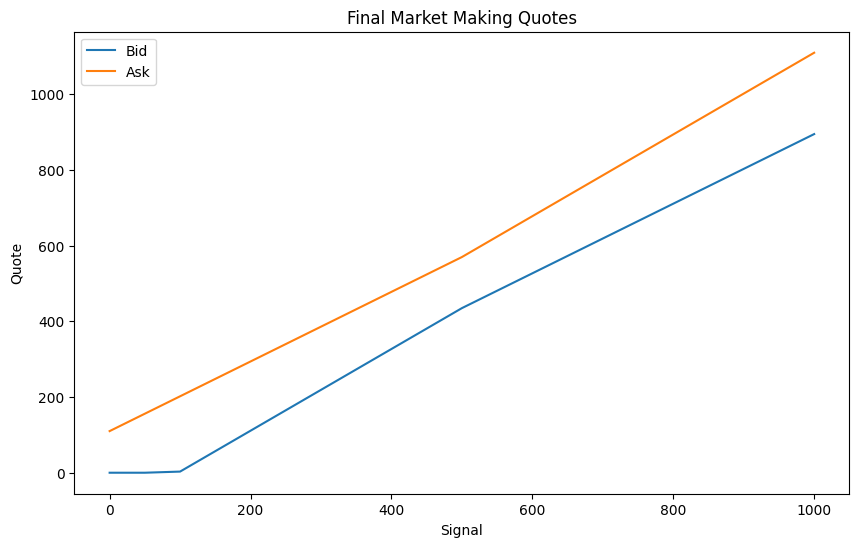

In [13]:
plt.figure(figsize=(10,6))

plt.plot(
    submission_df['signal'],
    submission_df['bid'],
    label='Bid'
)

plt.plot(
    submission_df['signal'],
    submission_df['ask'],
    label='Ask'
)

plt.xlabel("Signal")
plt.ylabel("Quote")
plt.title("Final Market Making Quotes")
plt.legend()

plt.show()